In [1]:
import os
import torch
import numpy as np
import pyexr
import matplotlib.pyplot as plt

In [ ]:
test_index = "5500" 
# Point to your separate prediction folders/files
# pred_dir = r"C:\Users\Kai Kumano\workspace\CGH-depth\results\engineered_predictions"
pred_dir = r"C:\Users\Kai Kumano\workspace\CGH-depth\results\baseline_predictions"
# pred_dir = r"C:\Users\Kai Kumano\workspace\CGH-depth\dataset\KOREATECH-CGH-512-3.6Mu\test\pred"
amp_file_path = os.path.join(pred_dir, f"prediction_{test_index}_amp.exr")
phs_file_path = os.path.join(pred_dir, f"prediction_{test_index}_phs.exr")
# amp_file_path = os.path.join(pred_dir, f"amp.exr")
# phs_file_path = os.path.join(pred_dir, f"phs.exr")
recon_save_dir = rf"C:\Users\Kai Kumano\workspace\CGH-depth\results\reconstructions\engineered_{test_index}"
recon_save_dir = rf"C:\Users\Kai Kumano\workspace\CGH-depth\results\reconstructions\baseline_{test_index}"
os.makedirs(recon_save_dir, exist_ok=True)

# Hardware and Physics Parameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PITCH = 3.6e-6      # 3.6 micrometers
WAVELENGTH = 638e-9 # 638 nanometers (Red)

In [3]:
def reconstruct_asm(amp, phs, z, pitch=3.6e-6, wavelength=638e-9):
    res_y, res_x = amp.shape
    u_hologram = torch.complex(amp * torch.cos(phs), amp * torch.sin(phs))
    u_freq = torch.fft.fftshift(torch.fft.fft2(u_hologram))
    
    fy = torch.fft.fftfreq(res_y, d=pitch, device=amp.device)
    fx = torch.fft.fftfreq(res_x, d=pitch, device=amp.device)
    fyy, fxx = torch.meshgrid(fy, fx, indexing='ij')
    fyy, fxx = torch.fft.fftshift(fyy), torch.fft.fftshift(fxx)
    
    k = 2 * np.pi / wavelength
    term = 1 - (wavelength * fxx)**2 - (wavelength * fyy)**2
    kernel = torch.exp(1j * k * z * torch.sqrt(torch.clamp(term, min=0)))
    
    u_reconstructed = torch.fft.ifft2(torch.fft.ifftshift(u_freq * kernel))
    return torch.abs(u_reconstructed)**2

Saved: C:\Users\Kai Kumano\workspace\CGH-depth\results\reconstructions\engineered_{test_index}\recon_idx5500_5mm.png
Saved: C:\Users\Kai Kumano\workspace\CGH-depth\results\reconstructions\engineered_{test_index}\recon_idx5500_10mm.png
Saved: C:\Users\Kai Kumano\workspace\CGH-depth\results\reconstructions\engineered_{test_index}\recon_idx5500_15mm.png
Saved: C:\Users\Kai Kumano\workspace\CGH-depth\results\reconstructions\engineered_{test_index}\recon_idx5500_20mm.png
Saved: C:\Users\Kai Kumano\workspace\CGH-depth\results\reconstructions\engineered_{test_index}\recon_idx5500_25mm.png


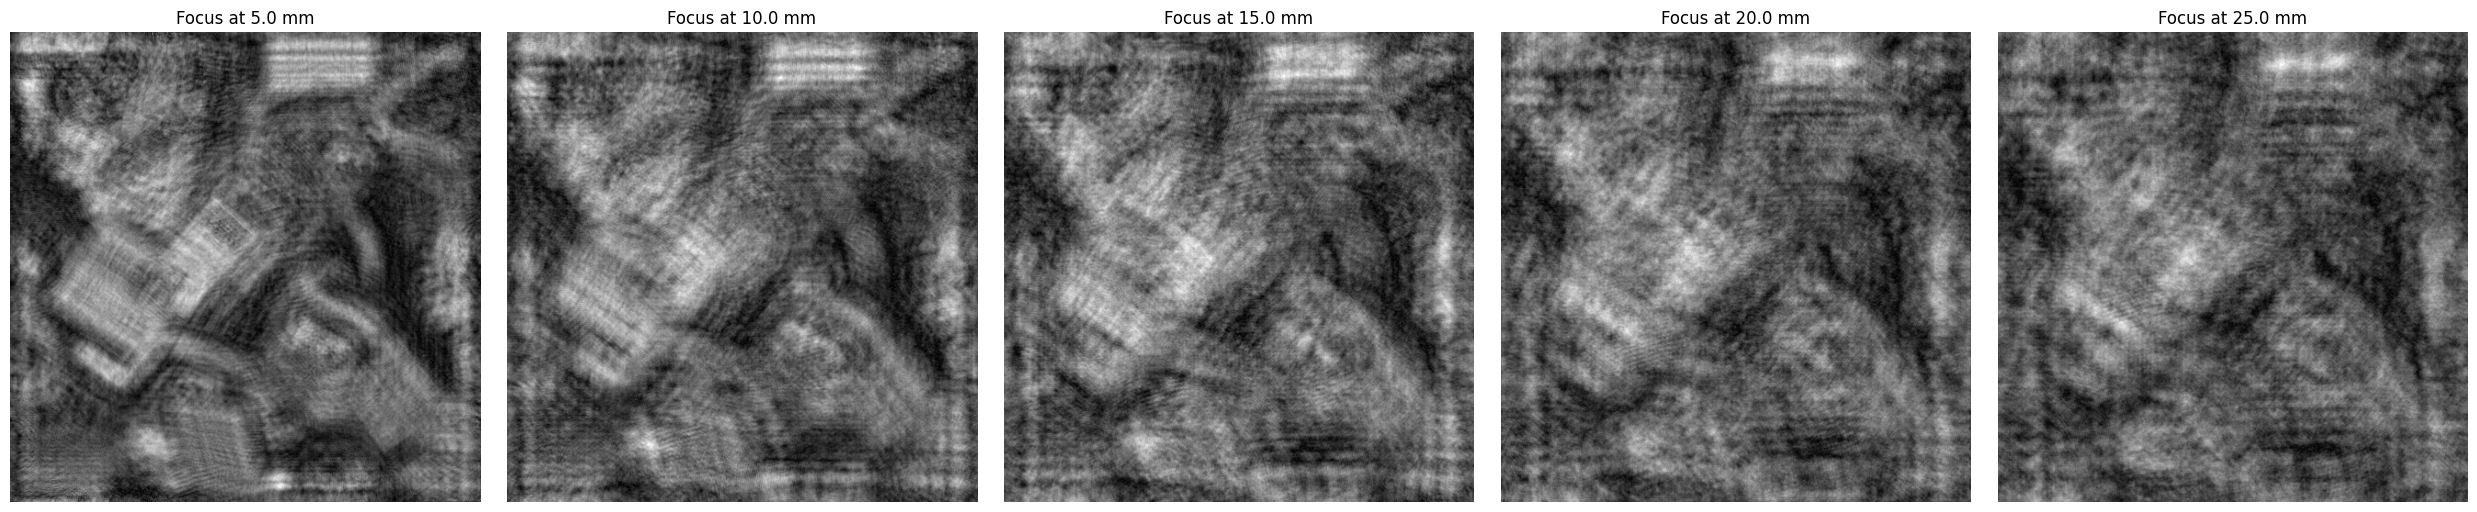

In [4]:
if not os.path.exists(amp_file_path) or not os.path.exists(phs_file_path):
    print(f"ERROR: Files not found at:\n{amp_file_path}\n{phs_file_path}")
else:
    # Load Amplitude EXR
    amp_data = pyexr.open(amp_file_path).get().astype(np.float32)
    # If the EXR is 3-channel, take the first one
    if amp_data.ndim == 3: amp_data = amp_data[:, :, 0]
    pred_amp = torch.from_numpy(amp_data).to(device)

    # Load Phase EXR
    phs_data = pyexr.open(phs_file_path).get().astype(np.float32)
    if phs_data.ndim == 3: phs_data = phs_data[:, :, 0]
    pred_phs = torch.from_numpy(phs_data).to(device)

    # %% 4. FOCUS SWEEP & SAVING
    depths_to_test = [0.005, 0.010, 0.015, 0.020, 0.025] 

    plt.figure(figsize=(25, 5))

    for i, z in enumerate(depths_to_test):
        # 1. Perform reconstruction
        recon_intensity = reconstruct_asm(pred_amp, pred_phs, z, pitch=PITCH, wavelength=WAVELENGTH)
        
        # 2. Process for saving
        recon_np = recon_intensity.cpu().numpy()
        recon_normalized = np.sqrt(recon_np) 
        
        # 3. Define filename and save
        file_name = f"recon_idx{test_index}_{int(z*1000)}mm.png"
        save_path = os.path.join(recon_save_dir, file_name)
        
        plt.imsave(save_path, recon_normalized, cmap='gray')
        print(f"Saved: {save_path}")

        # 4. Display in Jupyter
        plt.subplot(1, len(depths_to_test), i+1)
        plt.imshow(recon_normalized, cmap='gray')
        plt.title(f"Focus at {z*1000:.1f} mm")
        plt.axis('off')

    plt.tight_layout()
    plt.show()